#### Importing required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [2]:
# Import datasets
training_data_path = r"C:\Users\Akash\Documents\Intrusion_Detection\Dataset\UNSW_NB15_training-set.csv"
testing_data_path = r"C:\Users\Akash\Documents\Intrusion_Detection\Dataset\UNSW_NB15_testing-set.csv"

In [3]:
df_train = pd.read_csv(training_data_path)
df_test = pd.read_csv(testing_data_path)

# Combine datasets
df = pd.concat([df_train, df_test], axis=0)

### Exploratory Data Analysis

In [4]:
# Inspecting the dataset
print(f"Number of rows in the combined dataset: {df.shape[0]}")
print(f"Number of columns in the combined dataset: {df.shape[1]}")
print(df.info())

Number of rows in the combined dataset: 257673
Number of columns in the combined dataset: 45
<class 'pandas.core.frame.DataFrame'>
Index: 257673 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss       

In [5]:
# Understanding the features
pd.set_option('display.max_columns', None)
print(df.head())


   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  sttl  dttl        sload  dload  sloss  dloss  sinpkt  dinpkt  \
0   90909.0902   254     0  180363632.0    0.0      0      0   0.011     0.0   
1  125000.0003   254     0  881000000.0    0.0      0      0   0.008     0.0   
2  200000.0051   254     0  854400000.0    0.0      0      0   0.005     0.0   
3  166666.6608   254     0  600000000.0    0.0      0      0   0.006     0.0   
4  100000.0025   254     0  850400000.0    0.0      0      0   0.010     0.0   

   sjit  djit  swin  stcpb  dtcpb  dwin  tcprtt  synack  ackdat  smean  dmean  \
0   0.0   0.0     0    

In [6]:
# Checking for missing values in the dataset
missing_values = df.isnull().sum().to_dict()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
{'id': 0, 'dur': 0, 'proto': 0, 'service': 0, 'state': 0, 'spkts': 0, 'dpkts': 0, 'sbytes': 0, 'dbytes': 0, 'rate': 0, 'sttl': 0, 'dttl': 0, 'sload': 0, 'dload': 0, 'sloss': 0, 'dloss': 0, 'sinpkt': 0, 'dinpkt': 0, 'sjit': 0, 'djit': 0, 'swin': 0, 'stcpb': 0, 'dtcpb': 0, 'dwin': 0, 'tcprtt': 0, 'synack': 0, 'ackdat': 0, 'smean': 0, 'dmean': 0, 'trans_depth': 0, 'response_body_len': 0, 'ct_srv_src': 0, 'ct_state_ttl': 0, 'ct_dst_ltm': 0, 'ct_src_dport_ltm': 0, 'ct_dst_sport_ltm': 0, 'ct_dst_src_ltm': 0, 'is_ftp_login': 0, 'ct_ftp_cmd': 0, 'ct_flw_http_mthd': 0, 'ct_src_ltm': 0, 'ct_srv_dst': 0, 'is_sm_ips_ports': 0, 'attack_cat': 0, 'label': 0}


In [7]:
# Checking for duplicate rows in the dataset 

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
# Check unique values
for column in df.columns:
    unique_vals = df[column].value_counts()
    print(f"\nUnique values in '{column}' ({len(unique_vals)} unique values):")
    print(unique_vals)


Unique values in 'id' (175341 unique values):
id
1         2
54837     2
54895     2
54894     2
54893     2
         ..
113333    1
113332    1
113331    1
113330    1
175341    1
Name: count, Length: 175341, dtype: int64

Unique values in 'dur' (109945 unique values):
dur
0.000009    28577
0.000003    15862
0.000008    15572
0.000005     9356
0.000004     8362
            ...  
2.123287        1
2.042059        1
2.034334        1
2.091060        1
1.557125        1
Name: count, Length: 109945, dtype: int64

Unique values in 'proto' (133 unique values):
proto
tcp       123041
udp        92701
unas       15599
arp         3846
ospf        3271
           ...  
netblt       131
rdp          131
igmp          48
icmp          15
rtp            1
Name: count, Length: 133, dtype: int64

Unique values in 'service' (13 unique values):
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
ftp           4980
pop3          1528
ssh           15

#### Insights from data 
Data is clean but it requires further processing for categorical columns and such using one hot encoding.
Removing of unnecessary columns is required

In [9]:
print(df['service'].unique())

['-' 'http' 'ftp' 'ftp-data' 'smtp' 'pop3' 'dns' 'snmp' 'ssl' 'dhcp' 'irc'
 'radius' 'ssh']


In [10]:
# Replace '-' with None for all columns in the DataFrame
df = df.replace('-', 'None')

#### Distribution of Network Services in the Dataset 

C:\Users\Akash\AppData\Local\Temp\ipykernel_11808\28060439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='service', palette='viridis')


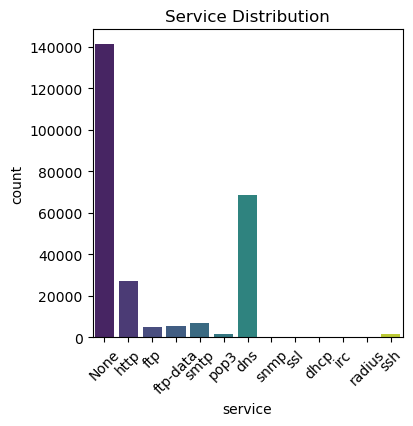

In [11]:
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='service', palette='viridis')
plt.title('Service Distribution')
plt.xticks(rotation=45)
plt.show()

### Basic Preprocessing

In [12]:
 #Convert the 'is_ftp_login' column to binary 
df['is_ftp_login'] = (df['is_ftp_login'] > 0).astype(int)

#### Summary Statistics for the Dataset

In [13]:
print("\nSummary statistics for the dataset:")
print(df.describe().T)



Summary statistics for the dataset:
                      count          mean           std   min           25%  \
id                 257673.0  7.281182e+04  4.892992e+04   1.0  32210.000000   
dur                257673.0  1.246715e+00  5.974305e+00   0.0      0.000008   
spkts              257673.0  1.977714e+01  1.359472e+02   1.0      2.000000   
dpkts              257673.0  1.851470e+01  1.119860e+02   0.0      0.000000   
sbytes             257673.0  8.572952e+03  1.737739e+05  24.0    114.000000   
dbytes             257673.0  1.438729e+04  1.461993e+05   0.0      0.000000   
rate               257673.0  9.125391e+04  1.603446e+05   0.0     30.789277   
sttl               257673.0  1.800009e+02  1.024883e+02   0.0     62.000000   
dttl               257673.0  8.475496e+01  1.127621e+02   0.0      0.000000   
sload              257673.0  7.060869e+07  1.857313e+08   0.0  12318.004880   
dload              257673.0  6.582143e+05  2.412372e+06   0.0      0.000000   
sloss          

In [14]:
print(f"\nShape of the dataset: Rows: {df.shape[0]}, Columns: {df.shape[1]}")



Shape of the dataset: Rows: 257673, Columns: 45


#### Distribution of attack categories

Here are the one-line definitions in bullet points:

- **Normal**: Regular, non-malicious traffic or activity.
- **Generic**: An attack that targets multiple platforms or encryption algorithms, often focusing on cryptographic weaknesses.
- **Exploits**: Attacks that take advantage of software vulnerabilities to gain unauthorized access or control.
- **Fuzzers**: Tools or techniques that send random or malformed data to systems to find bugs or vulnerabilities.
- **DoS (Denial of Service)**: An attack designed to make a service unavailable by overwhelming it with traffic.
- **Reconnaissance**: Techniques used to gather information about a system to prepare for an attack.
- **Analysis**: Examining data or system behaviors to identify malicious activities.
- **Backdoor**: A hidden way to access a system that bypasses normal authentication processes.
- **Shellcode**: Small malicious code used in exploiting a vulnerability to gain control of a system.
- **Worms**: Self-replicating malware that spreads across networks, often causing damage or disruption.

C:\Users\Akash\AppData\Local\Temp\ipykernel_11808\3121784064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=attack_counts.index, y=attack_counts.values, palette='viridis')


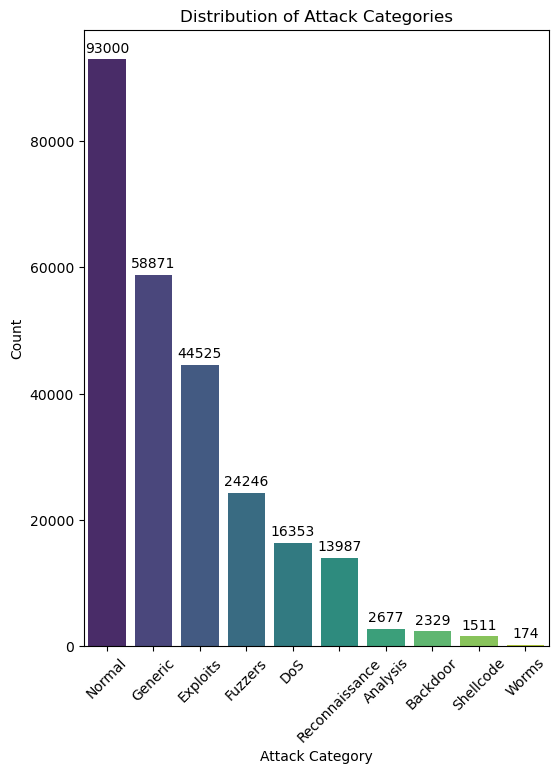

In [15]:
attack_counts = df['attack_cat'].value_counts()
plt.figure(figsize=(6, 8))
bar_plot = sns.barplot(x=attack_counts.index, y=attack_counts.values, palette='viridis')
for bar in bar_plot.patches:
    bar_plot.annotate(format(bar.get_height(), '.0f'),
                      (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='center', xytext=(0, 8),
                      textcoords='offset points')
plt.title('Distribution of Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Distribution of Numerical Features in the Dataset

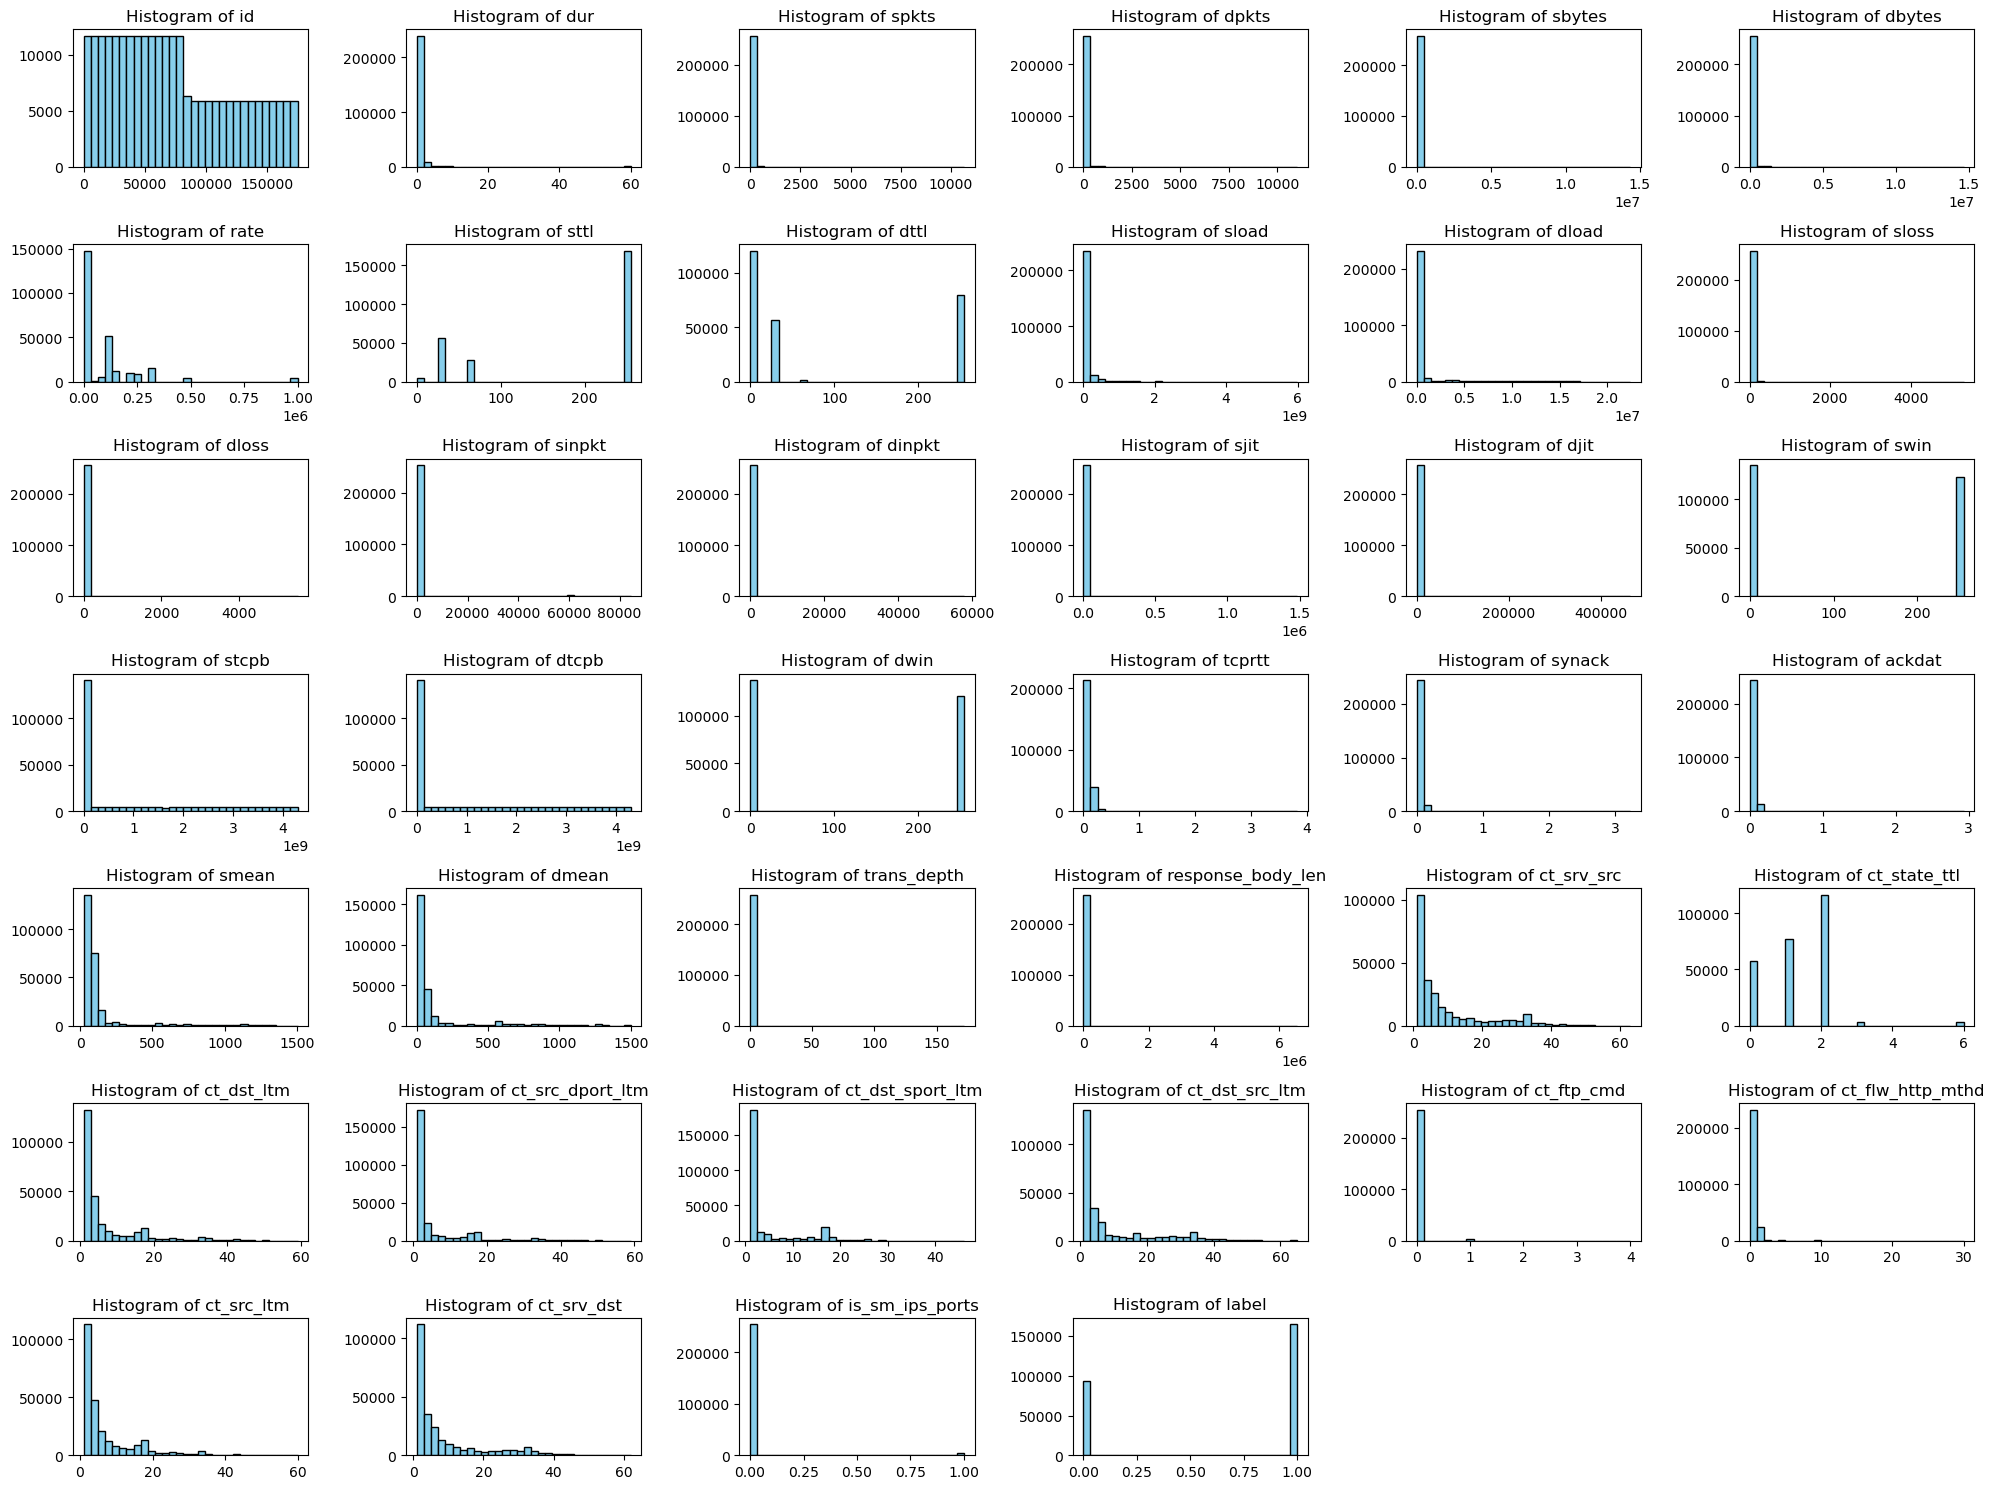

In [16]:
import math
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the number of rows and columns for subplots dynamically
num_features = len(numeric_features)
num_cols = 6  # Set the number of columns
num_rows = math.ceil(num_features / num_cols)  # Calculate the number of rows needed

plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {feature}')

plt.tight_layout()
plt.show()


#### Count plot for state  

C:\Users\Akash\AppData\Local\Temp\ipykernel_11808\1059007925.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


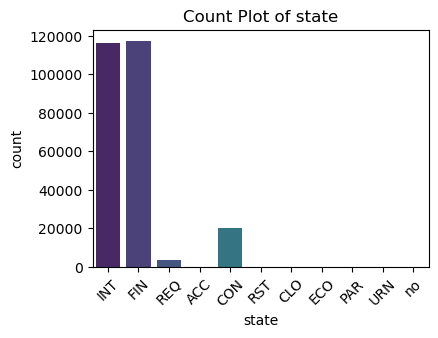

In [17]:
categorical_features = ['state']

plt.figure(figsize=(8, 6))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Count Plot of {feature}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Removing unnecessary columns 

In [18]:
# Remove 'id' and 'attack_cat' columns as it does
df = df.drop(columns=['id', 'attack_cat'])

#### Outlier detection using box plots


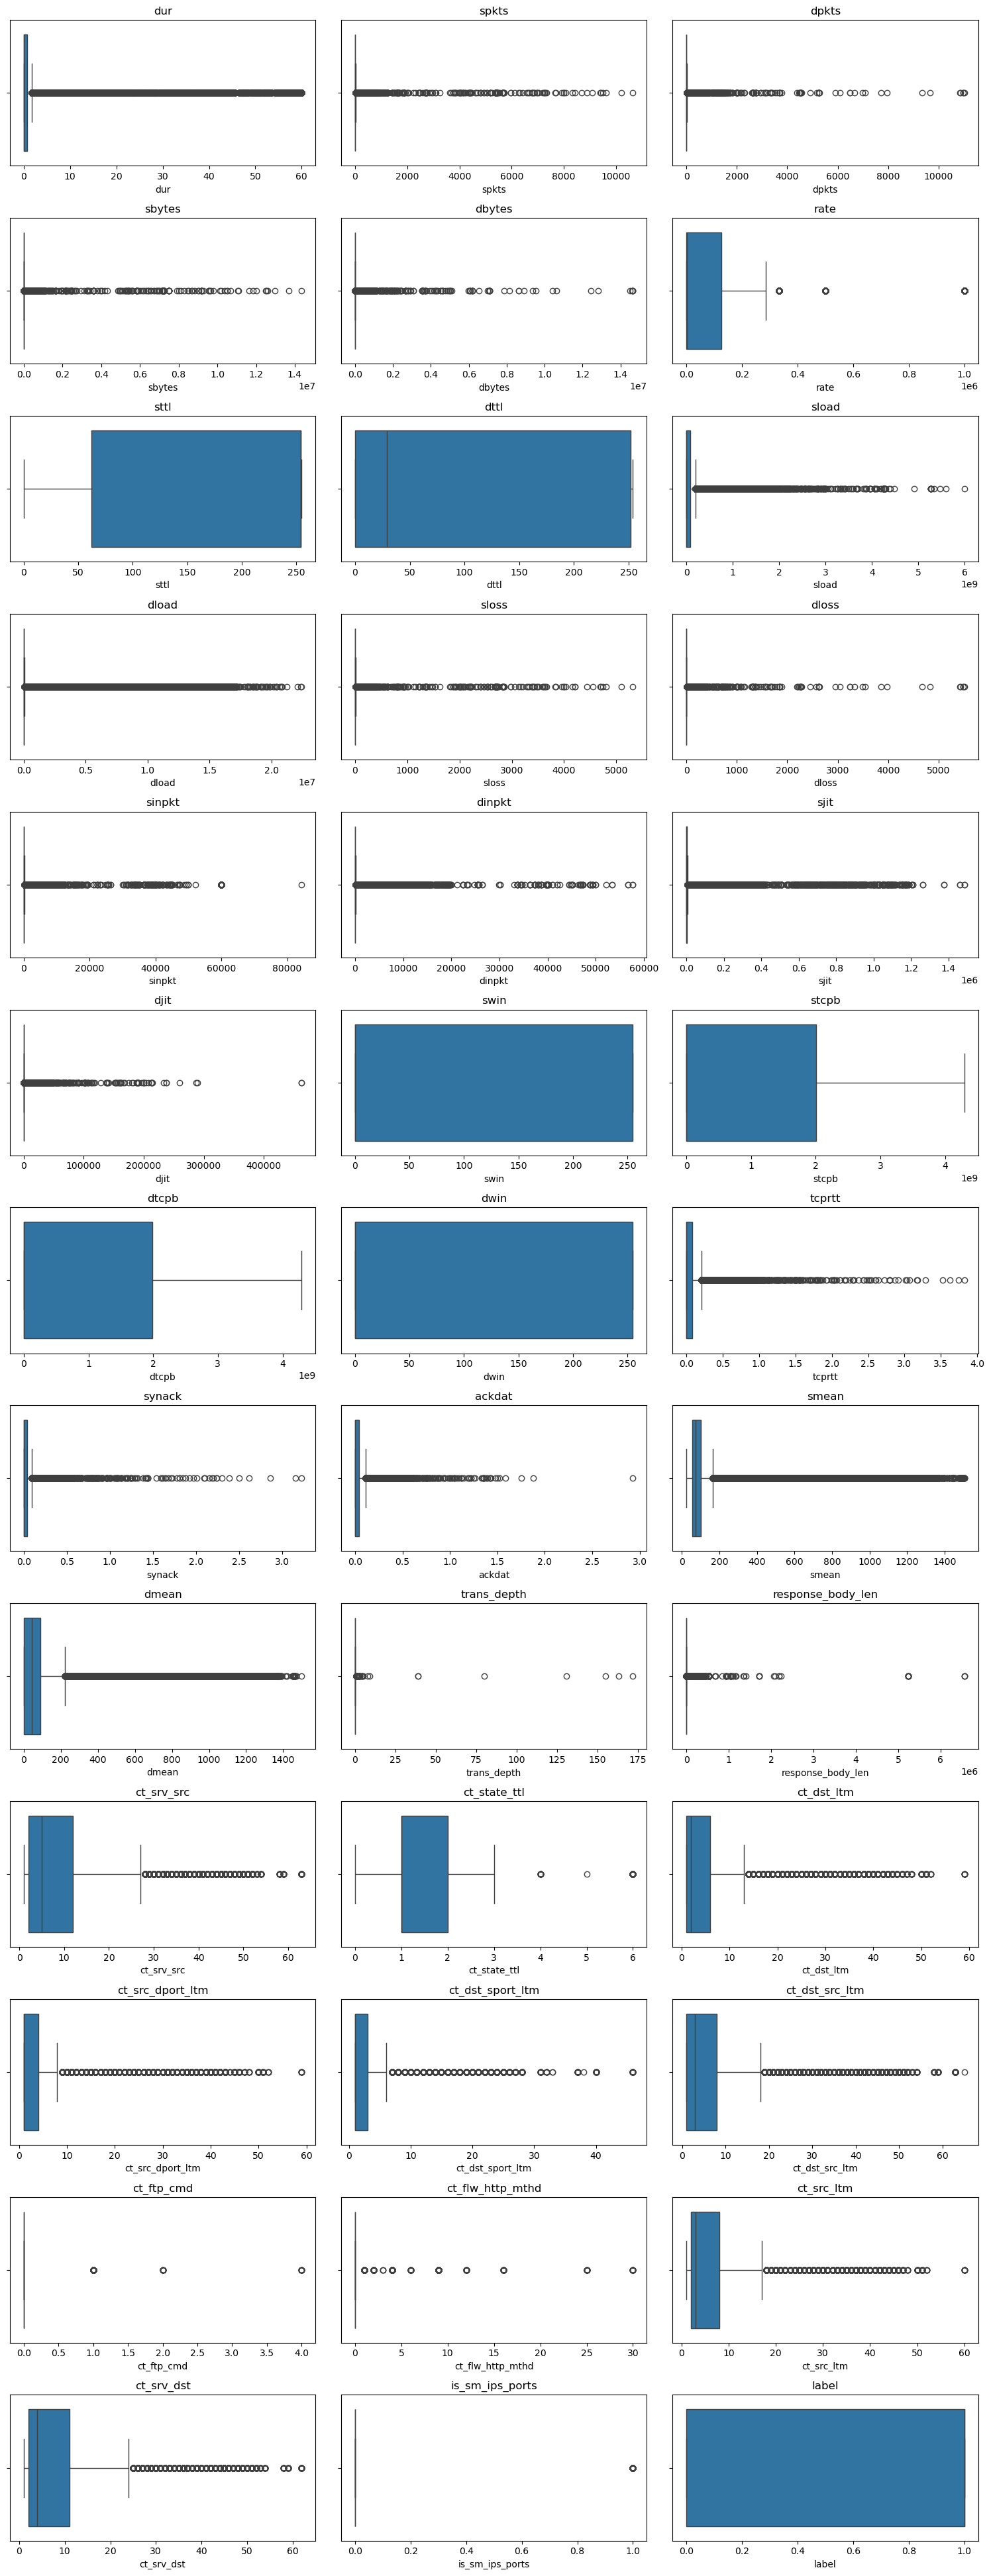

In [19]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features = len(numeric_features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3))
axes = axes.flatten()
for i, feature in enumerate(numeric_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f'{feature}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


#### Checking if the target variable is balanced

In [20]:
target_distribution = df['label'].value_counts()
print("Distribution of target variable:")
print(target_distribution)


Distribution of target variable:
label
1    164673
0     93000
Name: count, dtype: int64


#### Distribution of target variable

C:\Users\Akash\AppData\Local\Temp\ipykernel_11808\3637990336.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#FF0000', '#000000'], edgecolor='black')


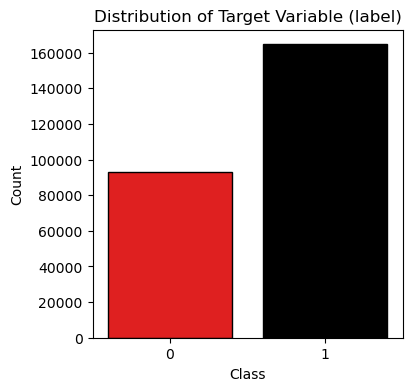

In [21]:
plt.figure(figsize=(4, 4))  

# Create the countplot 
sns.countplot(x='label', data=df, palette=['#FF0000', '#000000'], edgecolor='black')  
plt.title('Distribution of Target Variable (label)', color='black')
plt.xlabel('Class', color='black')
plt.ylabel('Count', color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')

# Set the background color to white
plt.gca().set_facecolor('white')

# Show the plot
plt.show()


#### One-Hot Encoding for categorical features


In [22]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Features to One-Hot Encode:", categorical_features)

Categorical Features to One-Hot Encode: ['proto', 'service', 'state']


In [23]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

#### Correlation Analysis and Removal of Highly Correlated Features

In [24]:
# Correlation analysis and removing highly correlated features
numerical_features = df_encoded.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_features.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = set()
high_corr_pairs = []

for column in upper_tri.columns:
    high_corr = upper_tri[column][upper_tri[column] > 0.80]
    if not high_corr.empty:
        to_drop.add(column)
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, corr_matrix.loc[column, idx]))

print("\nHighly correlated numerical columns (correlation > 0.80):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]} have a correlation of {pair[2]:.2f}")


Highly correlated numerical columns (correlation > 0.80):
sbytes and spkts have a correlation of 0.96
dbytes and dpkts have a correlation of 0.97
sloss and spkts have a correlation of 0.97
sloss and sbytes have a correlation of 1.00
dloss and dpkts have a correlation of 0.98
dloss and dbytes have a correlation of 1.00
dwin and swin have a correlation of 0.98
synack and tcprtt have a correlation of 0.94
ackdat and tcprtt have a correlation of 0.92
ct_dst_ltm and ct_srv_src have a correlation of 0.84
ct_src_dport_ltm and ct_srv_src have a correlation of 0.86
ct_src_dport_ltm and ct_dst_ltm have a correlation of 0.96
ct_dst_sport_ltm and ct_srv_src have a correlation of 0.81
ct_dst_sport_ltm and ct_dst_ltm have a correlation of 0.87
ct_dst_sport_ltm and ct_src_dport_ltm have a correlation of 0.91
ct_dst_src_ltm and ct_srv_src have a correlation of 0.95
ct_dst_src_ltm and ct_dst_ltm have a correlation of 0.86
ct_dst_src_ltm and ct_src_dport_ltm have a correlation of 0.87
ct_dst_src_ltm an

#### Correlation matrix

Generates a visually enhanced heatmap to display the correlation matrix of numerical features, highlighting feature relationships and avoiding redundancy by masking the upper triangle.

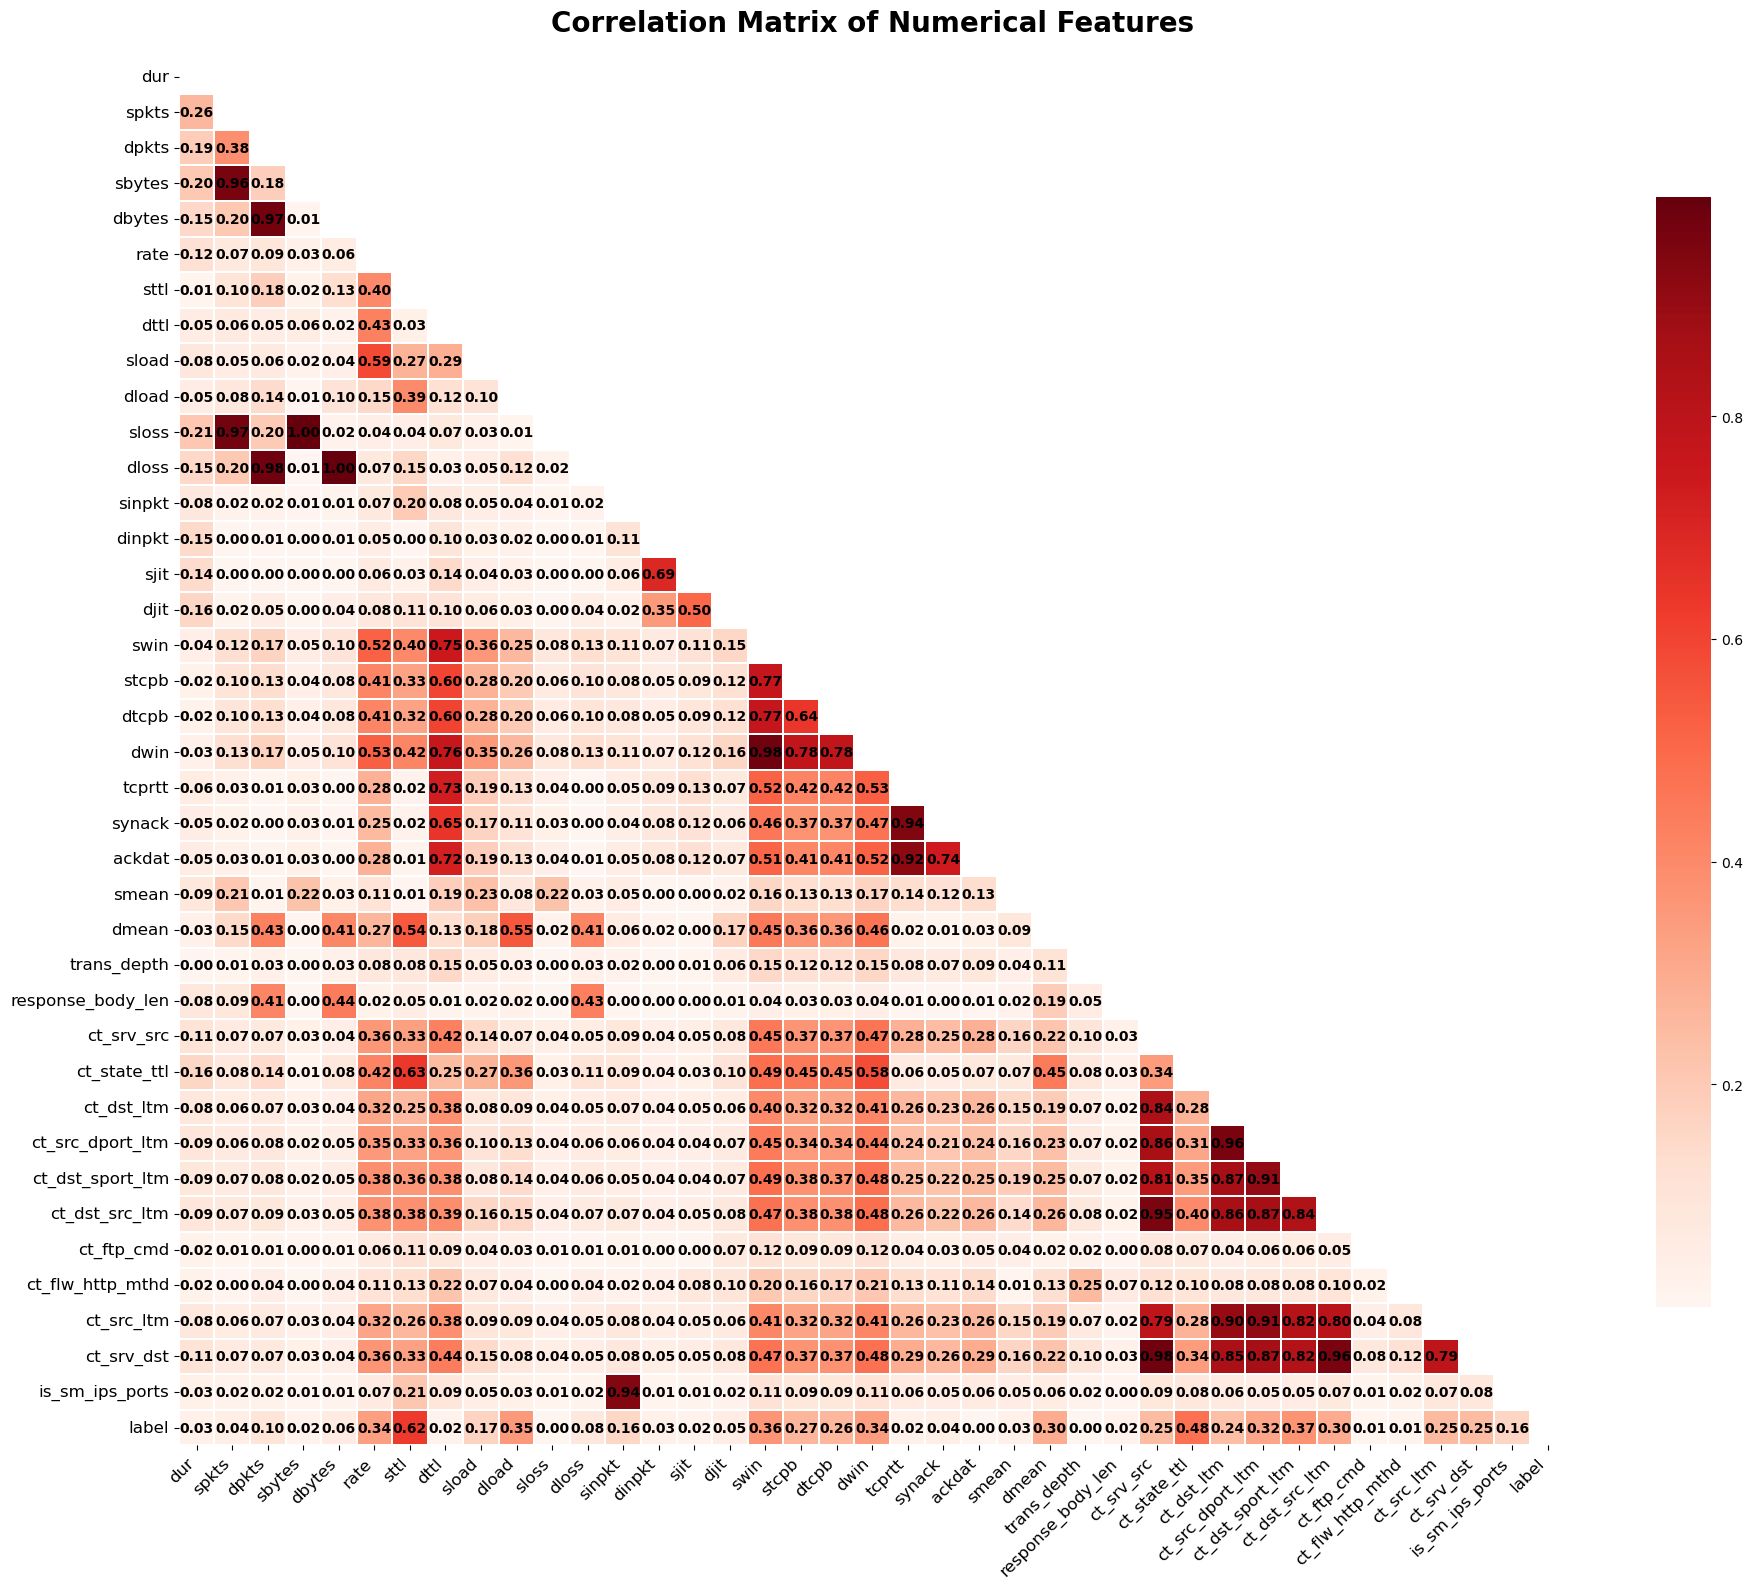

In [25]:

plt.figure(figsize=(20, 16)) 
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='Reds',  
    cbar=True,
    square=True, 
    linewidths=1.2,  
    annot_kws={"size": 10, "weight": "bold", "color": "black"},  
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool)), 
    cbar_kws={"shrink": 0.8, "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1]}, 
)


plt.title('Correlation Matrix of Numerical Features', fontsize=20, fontweight='bold', pad=20, color='black')  
plt.xticks(rotation=45, ha='right', fontsize=12, color='black')  
plt.yticks(fontsize=12, color='black')  
plt.tight_layout()  
plt.show()


#### Features correlating with the Label

Computes the correlation of numerical features with the target label and visualizes it as a heatmap, providing insights into which features are most strongly correlated with the label.

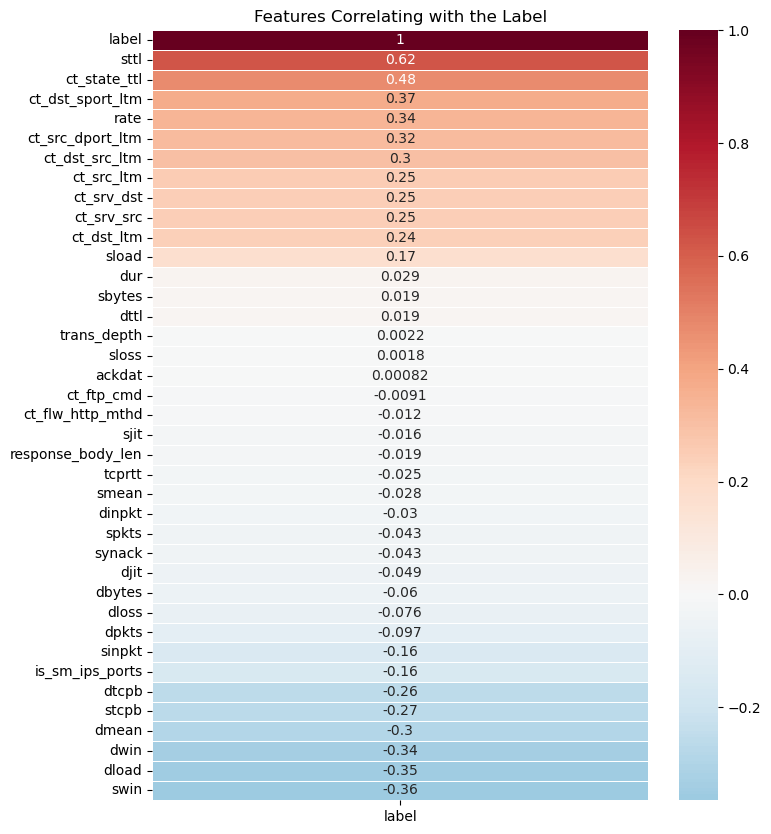

In [26]:

label_column = 'label' 

# Select only numerical features from the encoded dataframe, including the label
numerical_features = df_encoded.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numerical_features.corr()

# Extract correlation of all features with the label column
label_correlation = corr_matrix[[label_column]].sort_values(by=label_column, ascending=False)

# Plot the heatmap for correlation with the label
plt.figure(figsize=(8, 10))
sns.heatmap(label_correlation, annot=True, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Features Correlating with the Label')
plt.show()


### Key Insights:
- *High positive correlation*: `sttl (0.62)`, `ct_state_ttl (0.48)`, and `ct_dst_sport_ltm (0.37)` are strong predictors of the label.
- *Moderate correlation*: Features like `ct_src_dport_ltm (0.32)` and `ct_srv_dst (0.25)` have moderate predictive power.
- *Weak or negligible correlation*: Features such as `trans_depth (0.0022)` and `ackdat (0.00082)` show minimal influence on the label.
- *Negative correlation*: `swin (-0.36)` and `dload (-0.35)` exhibit moderate negative correlations.

In [27]:
# Drop highly correlated features
df_reduced = df_encoded.drop(columns=to_drop)
print("\nRemaining columns after dropping highly correlated features:")
print(df_reduced.columns.tolist())


Remaining columns after dropping highly correlated features:
['dur', 'spkts', 'dpkts', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'tcprtt', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'label', 'proto_a/n', 'proto_aes-sp3-d', 'proto_any', 'proto_argus', 'proto_aris', 'proto_arp', 'proto_ax.25', 'proto_bbn-rcc', 'proto_bna', 'proto_br-sat-mon', 'proto_cbt', 'proto_cftp', 'proto_chaos', 'proto_compaq-peer', 'proto_cphb', 'proto_cpnx', 'proto_crtp', 'proto_crudp', 'proto_dcn', 'proto_ddp', 'proto_ddx', 'proto_dgp', 'proto_egp', 'proto_eigrp', 'proto_emcon', 'proto_encap', 'proto_etherip', 'proto_fc', 'proto_fire', 'proto_ggp', 'proto_gmtp', 'proto_gre', 'proto_hmp', 'proto_i-nlsp', 'proto_iatp', 'proto_ib', 'proto_icmp', 'proto_idpr', 'proto_idpr-cmtp', 'proto_idrp', 'proto_ifmp', 'proto_igmp', 'proto_igp', 'proto_il', 'proto_ip', 'proto_ip

#### Data Splitting for modelling

In [28]:
# Split the data for modeling
X = df_reduced.drop('label', axis=1)
y = df_reduced['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Apply SMOTE to balance the data


In [29]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#### Checking if the target variable is balanced

C:\Users\Akash\AppData\Local\Temp\ipykernel_11808\2621282001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=pd.DataFrame(y_train_smote), palette=['red', 'black'])


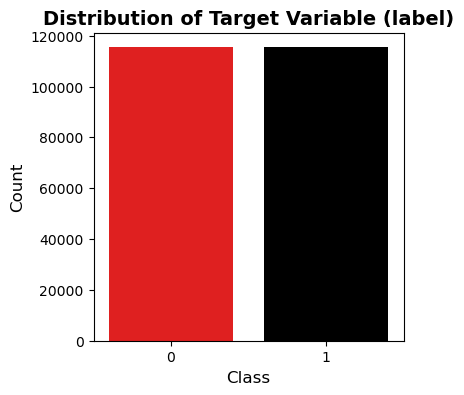

In [30]:
plt.figure(figsize=(4, 4))
sns.countplot(x='label', data=pd.DataFrame(y_train_smote), palette=['red', 'black'])  
plt.title('Distribution of Target Variable (label)', color='black', fontsize=14, fontweight='bold') 
plt.xlabel('Class', color='black', fontsize=12)  
plt.ylabel('Count', color='black', fontsize=12)  
plt.xticks(color='black')  
plt.yticks(color='black')  
plt.show()


#### Feature Scaling using RobustScaler

In [31]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

### Random Forest

In [32]:
# Train Random Forest on the SMOTE-balanced data and evaluate its performance on the test set.
#Train the model
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_scaled, y_train_smote)

# Predict from the model
y_pred_rf = rf_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy of the Random Forest classifier: {accuracy_rf:.2f}")
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))


Accuracy of the Random Forest classifier: 0.94
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     28026
           1       0.96      0.94      0.95     49276

    accuracy                           0.94     77302
   macro avg       0.93      0.94      0.93     77302
weighted avg       0.94      0.94      0.94     77302



<Figure size 400x400 with 0 Axes>

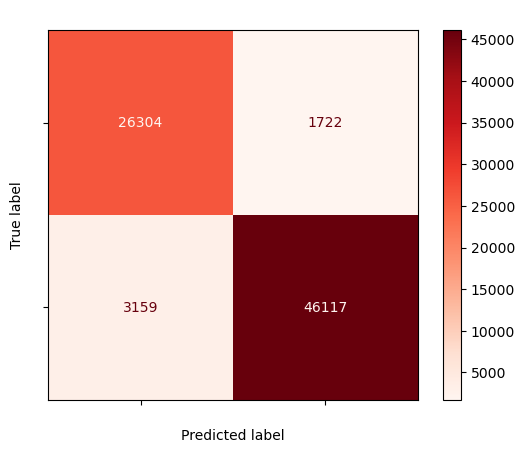

In [33]:
# Calculate the confusion matrix for random forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix 
plt.figure(figsize=(4, 4))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Reds')
plt.title('Confusion Matrix for Random Forest', color='white', fontsize=12, fontweight='bold')
plt.gca().set_facecolor('black')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()


#### Get feature importances from the random forest model


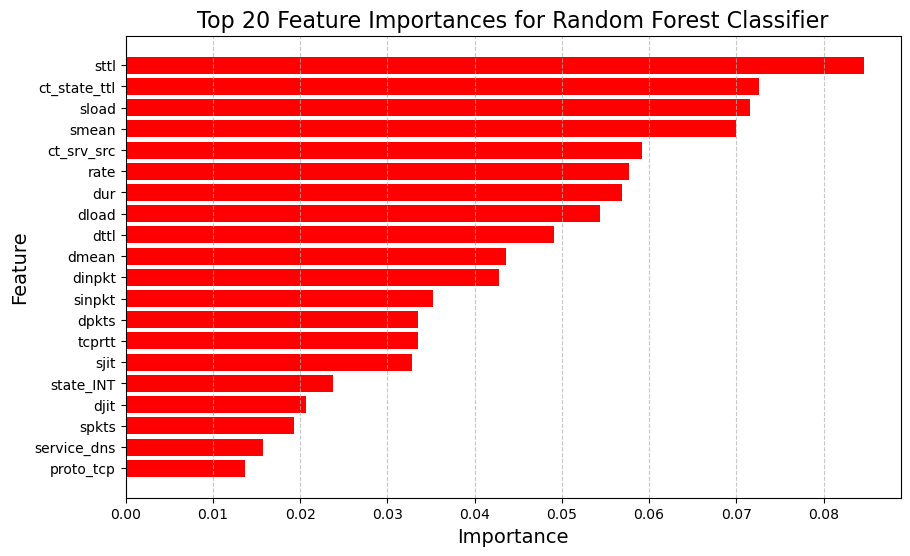

In [34]:
importances = rf_classifier.feature_importances_

# Get the feature names
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the DataFrame by importance values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select top 20 features for better readability
top_n = 20
top_features = feature_importance_df.head(top_n)

# Plot the feature importances for top N features
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='red')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.title('Top 20 Feature Importances for Random Forest Classifier', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


#### Random Forest Classifier Using Top N Features

In [35]:
# Train Random Forest using only the top N important features and evaluate its performance.

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Select top N important features
top_feature_names = top_features['Feature'].values

# Filter the training and testing sets to include only these important features
X_train_top_features = X_train_scaled_df[top_feature_names]
X_test_top_features = X_test_scaled_df[top_feature_names]

# Train Random Forest classifier using only the top features
rf_classifier_top = RandomForestClassifier(random_state=42)
rf_classifier_top.fit(X_train_top_features, y_train_smote)

# Make predictions using the top features
y_pred_rf_top = rf_classifier_top.predict(X_test_top_features)

# Calculate accuracy
accuracy_rf_top = accuracy_score(y_test, y_pred_rf_top)
print(f"\nAccuracy of the Random Forest classifier with top {top_n} features: {accuracy_rf_top:.2f}")

# Print classification report for the model using top features
print("Classification Report for Random Forest with Top Features:")
print(classification_report(y_test, y_pred_rf_top))



Accuracy of the Random Forest classifier with top 20 features: 0.93
Classification Report for Random Forest with Top Features:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     28026
           1       0.96      0.94      0.95     49276

    accuracy                           0.93     77302
   macro avg       0.93      0.93      0.93     77302
weighted avg       0.94      0.93      0.94     77302



### K-Nearest Neighbors


In [36]:
# Train K-Nearest Neighbors classifier and evaluate its accuracy and classification performance.
#Train the model
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, y_train_smote)

# Predict from the model
y_pred_knn = knn_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy of the K-Nearest Neighbors classifier: {accuracy_knn:.2f}")
print("Classification Report for K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_knn))


Accuracy of the K-Nearest Neighbors classifier: 0.91
Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     28026
           1       0.95      0.92      0.93     49276

    accuracy                           0.91     77302
   macro avg       0.90      0.91      0.91     77302
weighted avg       0.92      0.91      0.91     77302



<Figure size 400x400 with 0 Axes>

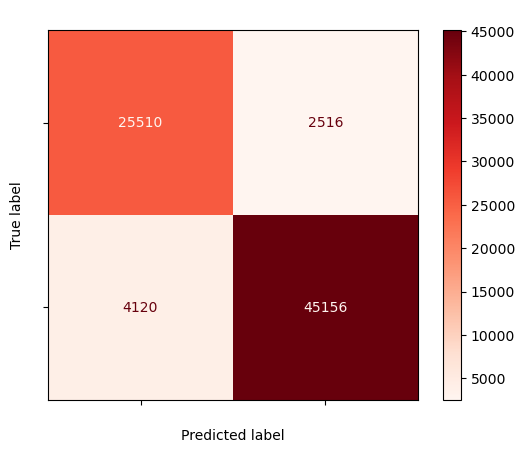

In [37]:
# Calculate the confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot the confusion matrix 
plt.figure(figsize=(4, 4))
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(cmap='Reds')  # Use 'Reds' color scheme
plt.title('Confusion Matrix for K-Nearest Neighbors', color='white', fontsize=12, fontweight='bold')
plt.gca().set_facecolor('black')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()


### Decision Tree


In [38]:
# Train Decision tree classifier and evaluate its accuracy and classification performance.

# Train the model
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_scaled, y_train_smote)

# Predict from the model
y_pred_dt = dt_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy of the Decision Tree classifier: {accuracy_dt:.2f}")
print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))


Accuracy of the Decision Tree classifier: 0.93
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     28026
           1       0.95      0.93      0.94     49276

    accuracy                           0.93     77302
   macro avg       0.92      0.92      0.92     77302
weighted avg       0.93      0.93      0.93     77302



<Figure size 400x400 with 0 Axes>

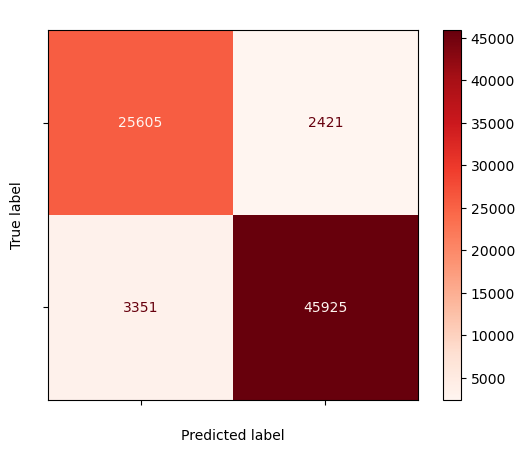

In [39]:
# Calculate the confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix 
plt.figure(figsize=(4, 4))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap='Reds')  
plt.title('Confusion Matrix for Decision Tree', color='white', fontsize=12, fontweight='bold')
plt.gca().set_facecolor('black')
plt.xticks(color='white')
plt.yticks(color='white')
plt.show()
